In [1]:
# !rm -rf '/content/DIS_Hughen'
# !git clone https://github.com/NU-Academics/DIS_Hughen.git

In [2]:
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
# df = pd.read_csv("/content/DIS_Hughen/undersampled_CIC2019_dataset.csv")

In [4]:
df.shape

(4685611, 90)

In [5]:
attack_set = df[df["label"] != "BENIGN"]
attack_sample = (attack_set.groupby("label", group_keys=False).sample(n=2000, random_state=42, replace=True).reset_index(drop=True))

In [6]:
attack_sample.shape

(36000, 90)

In [7]:
print(attack_sample["label"].value_counts())

label
DrDoS_DNS        2000
DrDoS_LDAP       2000
DrDoS_MSSQL      2000
DrDoS_NTP        2000
DrDoS_NetBIOS    2000
DrDoS_SNMP       2000
DrDoS_SSDP       2000
DrDoS_UDP        2000
LDAP             2000
MSSQL            2000
NetBIOS          2000
Portmap          2000
Syn              2000
TFTP             2000
UDP              2000
UDP-lag          2000
UDPLag           2000
WebDDoS          2000
Name: count, dtype: int64


In [8]:
benign_set = df[df["label"] == "BENIGN"]
benign_sample = benign_set.sample(n=attack_sample.shape[0], replace=True, random_state=42)

In [9]:
benign_sample.shape

(36000, 90)

In [10]:
print(benign_sample["label"].value_counts())

label
BENIGN    36000
Name: count, dtype: int64


In [11]:
df_sample =pd.concat([benign_sample, attack_sample]).reset_index(drop=True)

In [12]:
df_sample.shape

(72000, 90)

In [13]:
print(df_sample["label"].value_counts())

label
BENIGN           36000
DrDoS_DNS         2000
DrDoS_LDAP        2000
DrDoS_MSSQL       2000
DrDoS_NTP         2000
DrDoS_NetBIOS     2000
DrDoS_SNMP        2000
DrDoS_SSDP        2000
DrDoS_UDP         2000
LDAP              2000
MSSQL             2000
NetBIOS           2000
Portmap           2000
Syn               2000
TFTP              2000
UDP               2000
UDP-lag           2000
UDPLag            2000
WebDDoS           2000
Name: count, dtype: int64


In [14]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DrDoS_DNS': 1, 'DrDoS_LDAP': 2, 'DrDoS_MSSQL': 3, 'DrDoS_NTP': 4, 'DrDoS_NetBIOS': 5, 'DrDoS_SNMP': 6, 'DrDoS_SSDP': 7, 'DrDoS_UDP': 8, 'LDAP': 9, 'MSSQL': 10, 'NetBIOS': 11, 'Portmap': 12, 'Syn': 13, 'TFTP': 14, 'UDP': 15, 'UDP-lag': 16, 'UDPLag': 17, 'WebDDoS': 18}


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [ ]:
def extract_features(model, X, batch_size=8192):
    model.eval()
    dataset = torch.tensor(X.values, dtype=torch.float32)
    loader = DataLoader(dataset, batch_size=batch_size)

    features_list = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, features = model(batch)
            features_list.append(features.cpu().numpy())

    return np.vstack(features_list)

Z_train = extract_features(model, X_train)
Z_test = extract_features(model, X_test)

In [ ]:
X_train_hybrid = np.hstack([X_train.values, Z_train])
X_test_hybrid = np.hstack([X_test.values, Z_test])

In [16]:
model = XGBClassifier(
    n_estimators=300,   
    max_depth=6,
    learning_rate=0.03,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",
)
model.fit(X_train_hybrid, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


PermutationExplainer explainer: 1001it [07:50,  2.11it/s]                                                              


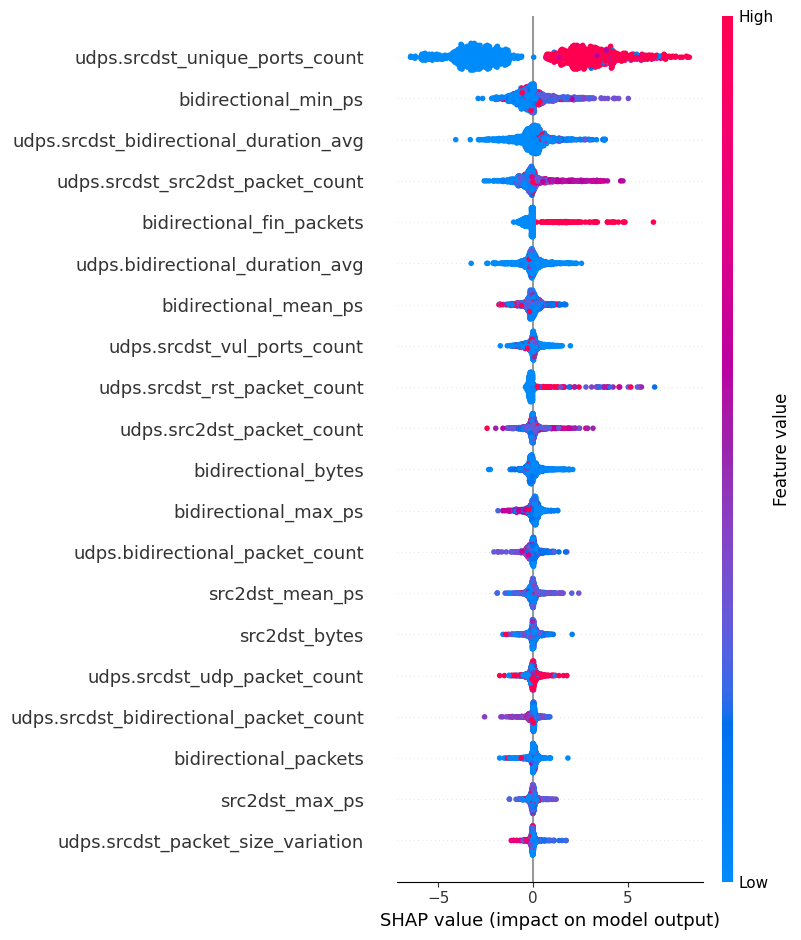

In [17]:
X_sample = X_test_hybrid.sample(1000, random_state=42)
explainer = shap.Explainer(model.predict, X_sample)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample, rng=np.random.default_rng(42))

In [18]:
y_pred = model.predict(X_test_hybrid)
y_prob = model.predict_proba(X_test_hybrid)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.8570833333333333
Weighted F1: 0.8537525166598353
Macro F1: 0.7229616354385421
ROC-AUC: 0.9945901096781306


In [19]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=le.classes_))

               precision    recall  f1-score   support

       BENIGN       1.00      1.00      1.00      7200
    DrDoS_DNS       0.55      0.57      0.56       400
   DrDoS_LDAP       0.41      0.40      0.40       400
  DrDoS_MSSQL       0.61      0.63      0.62       400
    DrDoS_NTP       1.00      0.99      1.00       400
DrDoS_NetBIOS       0.87      0.71      0.78       400
   DrDoS_SNMP       0.47      0.54      0.50       400
   DrDoS_SSDP       0.54      0.42      0.47       400
    DrDoS_UDP       0.47      0.43      0.45       400
         LDAP       0.57      0.52      0.54       400
        MSSQL       0.62      0.64      0.63       400
      NetBIOS       0.87      0.79      0.83       400
      Portmap       0.82      0.98      0.89       400
          Syn       1.00      0.99      1.00       400
         TFTP       1.00      1.00      1.00       400
          UDP       0.44      0.27      0.34       400
      UDP-lag       0.59      0.98      0.74       400
       UD